# lasso regularization 

## importing the necessary libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score

# sample dataset

In [4]:
x,y=make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=15,
    random_state=42
)

# split data into trianing and testing

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# train the lasso regression model

In [6]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


# make prediction and evluate performance

In [9]:
y_pred=lasso.predict(x_test)

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(mse)
print(r2)

262.30776655312474
0.9428029703899435


# regression line

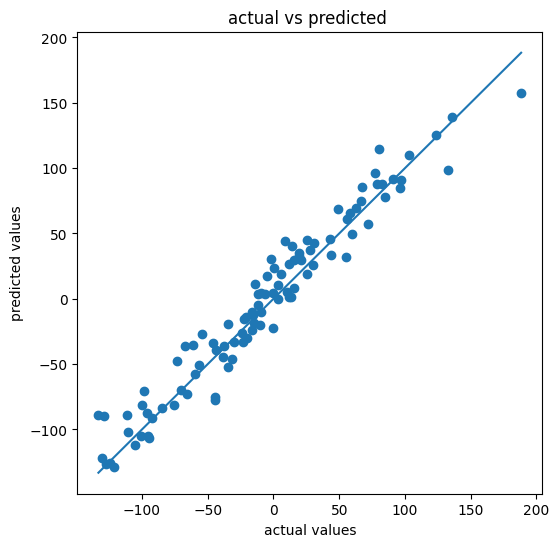

In [10]:
y_pred=lasso.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)

min_value=min(y_test.min(), y_pred.min())
max_value=max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel('actual values')
plt.ylabel('predicted values')
plt.title('actual vs predicted ')
plt.show()

# plot lasso coeffcients (feture selection)

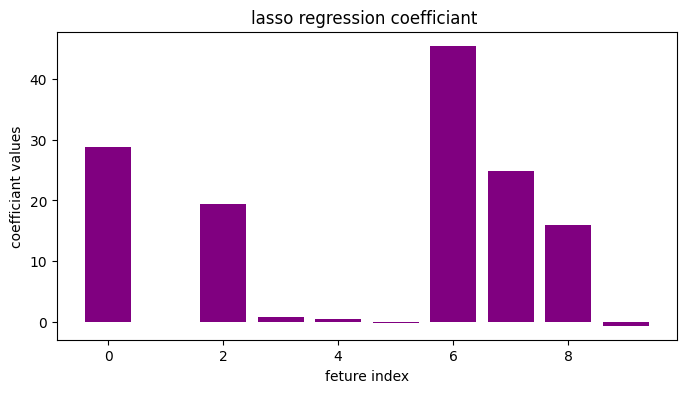

In [11]:
plt.figure(figsize=(8,4))
plt.bar(range(len(lasso.coef_)), lasso.coef_, color='purple')
plt.xlabel('feture index')
plt.ylabel('coefficiant values')
plt.title('lasso regression coefficiant ')
plt.show()

In [ ]:
# plot effect of regression s